Detected 10 distinct paper fragments.


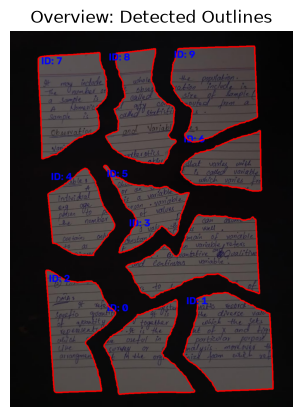

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
isolated_piece_list = []
def display_detected_fragments(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return
    
    # Convert from BGR to RGB for correct Matplotlib color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    
    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Otsu's thresholding to separate white paper from dark gaps
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter out tiny noise (keep only fragments larger than 1% of the total image area)
    min_area = (h * w) * 0.01  
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]
    
    print(f"Detected {len(fragments)} distinct paper fragments.")
    
    # 4. Draw bounding highlights on a copy of the original image
    highlighted_img = img_rgb.copy()
    
    # 5. Extract and plot each individual fragment
    num_fragments = len(fragments)
    
    # Create a grid layout to plot individual pieces side-by-side
    # We add +1 to the columns to show the overview image first
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols
    
    plt.figure(figsize=(15, rows * 4))
    
    # Plot 1: Show all detected areas on the original image
    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4) # Blue outline
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(highlighted_img, f"ID: {idx}", (x + 10, y + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")
    
    # Plot remaining subplots: Individual cropped pieces
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Isolate the current piece
        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        
        # Crop to its bounding box boundaries
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y:y+ph, x:x+pw]
        
        # plt.subplot(rows, cols, idx + 2)
        # plt.imshow(cropped_piece)
        # plt.title(f"Fragment ID: {idx}")
        # plt.axis("off")
        isolated_piece_list.append(cropped_piece)  # Store the isolated piece for later use

        
    plt.tight_layout()
    plt.show()

display_detected_fragments(r'D:\PythonProject1\Intern\Images\img78.jpeg')